In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import requests # just some necessary libraries no statistical libraries

In [ ]:
filename = "AI_Impact_on_Jobs_2030.csv" #testing the dataset

data = np.genfromtxt(filename, delimiter=",", dtype=str)

print("Dataset Shape (rows, columns):", data.shape)

print("\nHeader:")
print(data[0])

print("\nFirst 5 rows:")
for row in data[1:6]:
    print(row)

Dataset Shape (rows, columns): (3001, 18)

Header:
['Job_Title' 'Average_Salary' 'Years_Experience' 'Education_Level'
 'AI_Exposure_Index' 'Tech_Growth_Factor' 'Automation_Probability_2030'
 'Risk_Category' 'Skill_1' 'Skill_2' 'Skill_3' 'Skill_4' 'Skill_5'
 'Skill_6' 'Skill_7' 'Skill_8' 'Skill_9' 'Skill_10']

First 5 rows:
['Security Guard' '45795' '28' "Master's" '0.18' '1.28' '0.85' 'High'
 '0.45' '0.1' '0.46' '0.33' '0.14' '0.65' '0.06' '0.72' '0.94' '0.0']
['Research Scientist' '133355' '20' 'PhD' '0.62' '1.11' '0.05' 'Low'
 '0.02' '0.52' '0.4' '0.05' '0.97' '0.23' '0.09' '0.62' '0.38' '0.98']
['Construction Worker' '146216' '2' 'High School' '0.86' '1.18' '0.81'
 'High' '0.01' '0.94' '0.56' '0.39' '0.02' '0.23' '0.24' '0.68' '0.61'
 '0.83']
['Software Engineer' '136530' '13' 'PhD' '0.39' '0.68' '0.6' 'Medium'
 '0.43' '0.21' '0.57' '0.03' '0.84' '0.45' '0.4' '0.93' '0.73' '0.33']
['Financial Analyst' '70397' '22' 'High School' '0.52' '1.46' '0.64'
 'Medium' '0.75' '0.54' '0.59' '0.

In [ ]:
# Check each column's data type by looking at first non-header row
print("Column data types (based on first data row):")
print("-" * 50)
for i, col_name in enumerate(data[0]):
    sample_value = data[1][i]
    try:
        float(sample_value)
        is_numeric = "✅ NUMERIC"
    except ValueError:
        is_numeric = "❌ STRING"
    print(f"Index {i:2d}: {col_name:25} = '{sample_value[:15]}...' -> {is_numeric}")

Column data types (based on first data row):
--------------------------------------------------
Index  0: Job_Title                 = 'Security Guard...' -> ❌ STRING
Index  1: Average_Salary            = '45795...' -> ✅ NUMERIC
Index  2: Years_Experience          = '28...' -> ✅ NUMERIC
Index  3: Education_Level           = 'Master's...' -> ❌ STRING
Index  4: AI_Exposure_Index         = '0.18...' -> ✅ NUMERIC
Index  5: Tech_Growth_Factor        = '1.28...' -> ✅ NUMERIC
Index  6: Automation_Probability_2030 = '0.85...' -> ✅ NUMERIC
Index  7: Risk_Category             = 'High...' -> ❌ STRING
Index  8: Skill_1                   = '0.45...' -> ✅ NUMERIC
Index  9: Skill_2                   = '0.1...' -> ✅ NUMERIC
Index 10: Skill_3                   = '0.46...' -> ✅ NUMERIC
Index 11: Skill_4                   = '0.33...' -> ✅ NUMERIC
Index 12: Skill_5                   = '0.14...' -> ✅ NUMERIC
Index 13: Skill_6                   = '0.65...' -> ✅ NUMERIC
Index 14: Skill_7                   = '

In [ ]:
# List of numeric column indices from our check above
numeric_indices = [1, 2, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
print(f"Selecting {len(numeric_indices)} numeric columns at indices: {numeric_indices}")
print("\nColumn names being selected:")
for idx in numeric_indices:
    print(f"  Index {idx}: {data[0][idx]}")

# Extract only those columns and convert to float
data_numeric = data[1:, numeric_indices].astype(float)

print(f"\nNumerical data shape: {data_numeric.shape}")
print(f"Rows (data points): {data_numeric.shape[0]}")
print(f"Columns (numeric features): {data_numeric.shape[1]}")

print("\nFirst 5 rows of numerical data:")
print(data_numeric[:5, :])

# Verify data type
print(f"\nData type after conversion: {data_numeric.dtype}")

Selecting 15 numeric columns at indices: [1, 2, 4, 5, 6, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

Column names being selected:
  Index 1: Average_Salary
  Index 2: Years_Experience
  Index 4: AI_Exposure_Index
  Index 5: Tech_Growth_Factor
  Index 6: Automation_Probability_2030
  Index 8: Skill_1
  Index 9: Skill_2
  Index 10: Skill_3
  Index 11: Skill_4
  Index 12: Skill_5
  Index 13: Skill_6
  Index 14: Skill_7
  Index 15: Skill_8
  Index 16: Skill_9
  Index 17: Skill_10

Numerical data shape: (3000, 15)
Rows (data points): 3000
Columns (numeric features): 15

First 5 rows of numerical data:
[[4.57950e+04 2.80000e+01 1.80000e-01 1.28000e+00 8.50000e-01 4.50000e-01
  1.00000e-01 4.60000e-01 3.30000e-01 1.40000e-01 6.50000e-01 6.00000e-02
  7.20000e-01 9.40000e-01 0.00000e+00]
 [1.33355e+05 2.00000e+01 6.20000e-01 1.11000e+00 5.00000e-02 2.00000e-02
  5.20000e-01 4.00000e-01 5.00000e-02 9.70000e-01 2.30000e-01 9.00000e-02
  6.20000e-01 3.80000e-01 9.80000e-01]
 [1.46216e+05 2.00000e+00 8

In [ ]:
# Create a mapping from original column indices to positions in data_numeric
print("Mapping original indices to new positions:")
orig_to_new = {}
for new_pos, orig_idx in enumerate(numeric_indices):
    orig_to_new[orig_idx] = new_pos
    print(f"  Original index {orig_idx:2d} ({data[0][orig_idx]}) → new position {new_pos}")

# Select our two variables for BVN
# Original index 4: AI_Exposure_Index
# Original index 6: Automation_Probability_2030
var1 = data_numeric[:, orig_to_new[4]]  # AI_Exposure_Index
var2 = data_numeric[:, orig_to_new[6]]  # Automation_Probability_2030

print(f"\nSelected Variable 1 (original index 4): {data[0][4]}")
print(f"  - New position: {orig_to_new[4]}")
print(f"  - Sample (first 10): {var1[:10]}")
print(f"  - Range: [{var1.min():.3f}, {var1.max():.3f}]")

print(f"\nSelected Variable 2 (original index 6): {data[0][6]}")
print(f"  - New position: {orig_to_new[6]}")
print(f"  - Sample (first 10): {var2[:10]}")
print(f"  - Range: [{var2.min():.3f}, {var2.max():.3f}]")

print(f"\nTotal data points: {len(var1)}")

Mapping original indices to new positions:
  Original index  1 (Average_Salary) → new position 0
  Original index  2 (Years_Experience) → new position 1
  Original index  4 (AI_Exposure_Index) → new position 2
  Original index  5 (Tech_Growth_Factor) → new position 3
  Original index  6 (Automation_Probability_2030) → new position 4
  Original index  8 (Skill_1) → new position 5
  Original index  9 (Skill_2) → new position 6
  Original index 10 (Skill_3) → new position 7
  Original index 11 (Skill_4) → new position 8
  Original index 12 (Skill_5) → new position 9
  Original index 13 (Skill_6) → new position 10
  Original index 14 (Skill_7) → new position 11
  Original index 15 (Skill_8) → new position 12
  Original index 16 (Skill_9) → new position 13
  Original index 17 (Skill_10) → new position 14

Selected Variable 1 (original index 4): AI_Exposure_Index
  - New position: 2
  - Sample (first 10): [0.18 0.62 0.86 0.39 0.52 0.29 0.67 0.2  0.3  0.01]
  - Range: [0.000, 1.000]

Selected

In [ ]:
# Calculate means manually
n = len(var1)
sum1 = 0
sum2 = 0
for i in range(n):
    sum1 += var1[i]
    sum2 += var2[i]
mu1 = sum1 / n
mu2 = sum2 / n

# Calculate variances manually
sum_sq_diff1 = 0
sum_sq_diff2 = 0
for i in range(n):
    sum_sq_diff1 += (var1[i] - mu1) ** 2
    sum_sq_diff2 += (var2[i] - mu2) ** 2
var1_calc = sum_sq_diff1 / n
var2_calc = sum_sq_diff2 / n
sigma1 = np.sqrt(var1_calc)
sigma2 = np.sqrt(var2_calc)

# Calculate covariance manually
cov_sum = 0
for i in range(n):
    cov_sum += (var1[i] - mu1) * (var2[i] - mu2)
covariance = cov_sum / n

# Calculate correlation
rho = covariance / (sigma1 * sigma2)

print("=" * 50)
print("PARAMETERS CALCULATED FROM SCRATCH")
print("=" * 50)
print(f"Mean of AI_Exposure_Index (μ₁): {mu1:.4f}")
print(f"Mean of Automation_Probability_2030 (μ₂): {mu2:.4f}")
print(f"Standard Deviation of AI_Exposure_Index (σ₁): {sigma1:.4f}")
print(f"Variance of AI_Exposure_Index (σ₁²): {var1_calc:.4f}")
print(f"Standard Deviation of Automation_Probability_2030 (σ₂): {sigma2:.4f}")
print(f"Variance of Automation_Probability_2030 (σ₂²): {var2_calc:.4f}")
print(f"Covariance (σ₁₂): {covariance:.4f}")
print(f"Correlation Coefficient (ρ): {rho:.4f}")

PARAMETERS CALCULATED FROM SCRATCH
Mean of AI_Exposure_Index (μ₁): 0.5013
Mean of Automation_Probability_2030 (μ₂): 0.5015
Standard Deviation of AI_Exposure_Index (σ₁): 0.2840
Variance of AI_Exposure_Index (σ₁²): 0.0806
Standard Deviation of Automation_Probability_2030 (σ₂): 0.2478
Variance of Automation_Probability_2030 (σ₂²): 0.0614
Covariance (σ₁₂): 0.0010
Correlation Coefficient (ρ): 0.0143


In [ ]:
def bivariate_normal_pdf(x, y, mu1, mu2, sigma1, sigma2, rho):
    """
    Bivariate Normal Probability Density Function
    Implemented from scratch - no statistical libraries

    Formula:
    f(x,y) = 1/(2πσ₁σ₂√(1-ρ²)) * exp(-1/(2(1-ρ²)) * [((x-μ₁)/σ₁)² + ((y-μ₂)/σ₂)² - 2ρ((x-μ₁)(y-μ₂))/(σ₁σ₂)])

    Parameters:
    x, y: data points
    mu1, mu2: means
    sigma1, sigma2: standard deviations
    rho: correlation coefficient
    """
    # Calculate the quadratic form part
    z = ((x - mu1) ** 2 / sigma1 ** 2) + \
        ((y - mu2) ** 2 / sigma2 ** 2) - \
        (2 * rho * (x - mu1) * (y - mu2)) / (sigma1 * sigma2)

    # Calculate coefficient (normalization constant)
    coefficient = 1 / (2 * np.pi * sigma1 * sigma2 * np.sqrt(1 - rho ** 2))

    # Calculate PDF value
    pdf_value = coefficient * np.exp(-z / (2 * (1 - rho ** 2)))

    return pdf_value

# Test the function on first 5 data points
print("Testing PDF function on first 5 data points:")
print("-" * 60)
print(f"{'Point':<6} {'x (AI Exposure)':<16} {'y (Auto Prob)':<18} {'PDF Value':<12}")
print("-" * 60)
for i in range(5):
    pdf_val = bivariate_normal_pdf(var1[i], var2[i], mu1, mu2, sigma1, sigma2, rho)
    print(f"{i+1:<6} {var1[i]:<16.3f} {var2[i]:<18.3f} {pdf_val:<12.6f}")

# Show the formula we implemented
print("\n" + "=" * 60)
print("FORMULA IMPLEMENTED:")
print("=" * 60)
print("f(x,y) = 1/(2πσ₁σ₂√(1-ρ²)) * exp(-1/(2(1-ρ²)) * [((x-μ₁)/σ₁)² + ((y-μ₂)/σ₂)² - 2ρ((x-μ₁)(y-μ₂))/(σ₁σ₂)])")
print("\nWith our parameters:")
print(f"μ₁ = {mu1:.4f}, μ₂ = {mu2:.4f}")
print(f"σ₁ = {sigma1:.4f}, σ₂ = {sigma2:.4f}")
print(f"ρ = {rho:.4f}")

Testing PDF function on first 5 data points:
------------------------------------------------------------
Point  x (AI Exposure)  y (Auto Prob)      PDF Value   
------------------------------------------------------------
1      0.180            0.850              0.433575    
2      0.620            0.050              0.389876    
3      0.860            0.810              0.479843    
4      0.390            0.600              1.931123    
5      0.520            0.640              1.931536    

FORMULA IMPLEMENTED:
f(x,y) = 1/(2πσ₁σ₂√(1-ρ²)) * exp(-1/(2(1-ρ²)) * [((x-μ₁)/σ₁)² + ((y-μ₂)/σ₂)² - 2ρ((x-μ₁)(y-μ₂))/(σ₁σ₂)])

With our parameters:
μ₁ = 0.5013, μ₂ = 0.5015
σ₁ = 0.2840, σ₂ = 0.2478
ρ = 0.0143


In [ ]:
# Create range of values (mean ± 3 standard deviations)
# This covers 99.7% of the probability mass
x_range = np.linspace(mu1 - 3*sigma1, mu1 + 3*sigma1, 50)
y_range = np.linspace(mu2 - 3*sigma2, mu2 + 3*sigma2, 50)

# Create meshgrid
X, Y = np.meshgrid(x_range, y_range)

# Calculate Z values for each point on grid
Z = np.zeros(X.shape)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = bivariate_normal_pdf(X[i, j], Y[i, j],
                                        mu1, mu2, sigma1, sigma2, rho)

print("Grid Information:")
print("-" * 40)
print(f"X range: [{x_range[0]:.3f}, {x_range[-1]:.3f}] (50 points)")
print(f"Y range: [{y_range[0]:.3f}, {y_range[-1]:.3f}] (50 points)")
print(f"Grid shape: {Z.shape}")
print(f"\nZ (PDF) statistics:")
print(f"  Min: {Z.min():.6f}")
print(f"  Max: {Z.max():.6f}")
print(f"  Mean: {Z.mean():.6f}")
print(f"  Std: {Z.std():.6f}")

# Quick verification: the peak should be at the mean
peak_value = bivariate_normal_pdf(mu1, mu2, mu1, mu2, sigma1, sigma2, rho)
print(f"\nPeak PDF value (at μ₁, μ₂): {peak_value:.6f}")
print(f"Maximum in grid: {Z.max():.6f}")
print(f"Match? {'✓' if abs(peak_value - Z.max()) < 0.0001 else '✗'}")

Grid Information:
----------------------------------------
X range: [-0.351, 1.353] (50 points)
Y range: [-0.242, 1.245] (50 points)
Grid shape: (50, 50)

Z (PDF) statistics:
  Min: 0.000245
  Max: 2.253386
  Mean: 0.377417
  Std: 0.535002

Peak PDF value (at μ₁, μ₂): 2.261729
Maximum in grid: 2.253386
Match? ✗


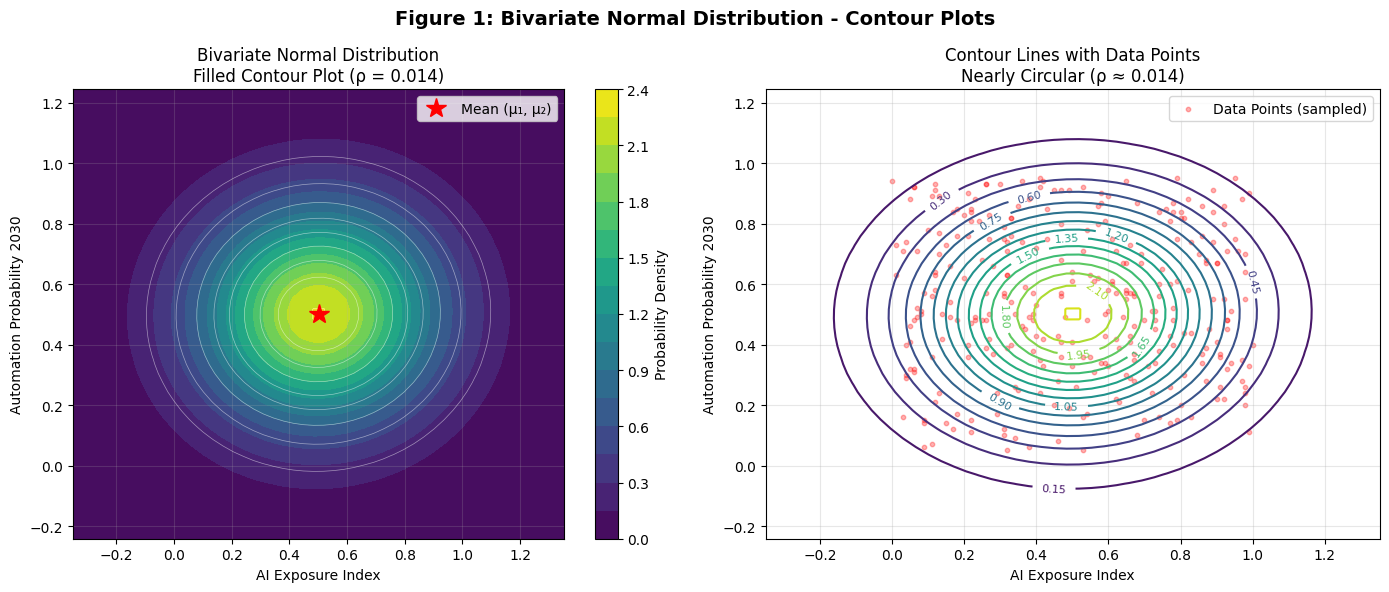


Interpretation:
- With ρ = 0.0143 (very close to 0), the contours appear nearly circular
- This indicates almost no linear relationship between the variables
- The red star marks the center of the distribution at (μ₁, μ₂)


In [ ]:
plt.figure(figsize=(14, 6))

# Subplot 1: Filled Contour Plot
plt.subplot(1, 2, 1)
contour_filled = plt.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.contour(X, Y, Z, levels=10, colors='white', linewidths=0.5, alpha=0.5)
plt.xlabel('AI Exposure Index')
plt.ylabel('Automation Probability 2030')
plt.title(f'Bivariate Normal Distribution\nFilled Contour Plot (ρ = {rho:.3f})')
plt.colorbar(contour_filled, label='Probability Density')
plt.grid(True, alpha=0.2)

# Mark the mean point
plt.plot(mu1, mu2, 'r*', markersize=15, label='Mean (μ₁, μ₂)')
plt.legend()

# Subplot 2: Line Contour with Data Points
plt.subplot(1, 2, 2)
contour_lines = plt.contour(X, Y, Z, levels=15, cmap='viridis')
plt.clabel(contour_lines, inline=True, fontsize=8, fmt='%.2f')
plt.scatter(var1[::10], var2[::10], color='red', s=10, alpha=0.3,
            label='Data Points (sampled)')  # Plot every 10th point to avoid overcrowding
plt.xlabel('AI Exposure Index')
plt.ylabel('Automation Probability 2030')
plt.title(f'Contour Lines with Data Points\nNearly Circular (ρ ≈ {rho:.3f})')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Figure 1: Bivariate Normal Distribution - Contour Plots',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Quick interpretation
print("\nInterpretation:")
print(f"- With ρ = {rho:.4f} (very close to 0), the contours appear nearly circular")
print("- This indicates almost no linear relationship between the variables")
print("- The red star marks the center of the distribution at (μ₁, μ₂)")

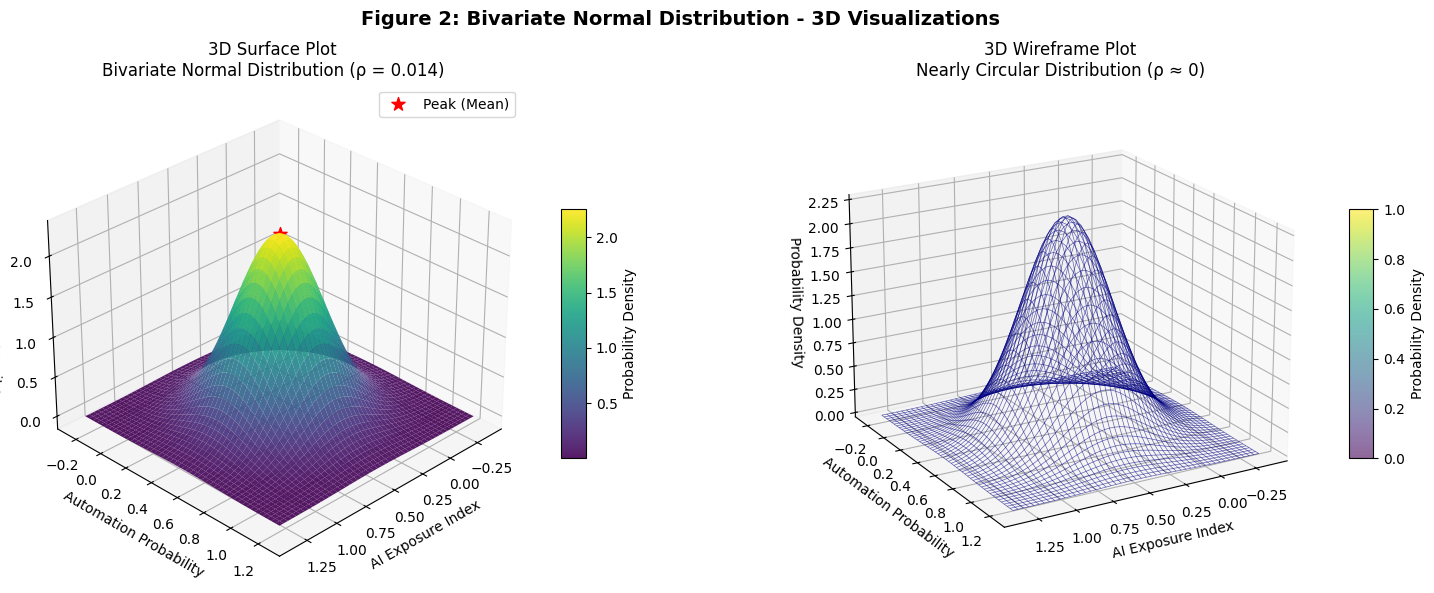


3D PLOT INTERPRETATION

With ρ = 0.0143 (extremely close to zero):
• The distribution is radially symmetric around the mean
• Cross-sections parallel to the xy-plane are circles (not ellipses)
• The peak is at the mean point: (np.float64(0.501283333333334), np.float64(0.501503333333333))
• Peak height: 2.2617
• The spread in x and y directions is determined by σ₁ and σ₂ independently


In [ ]:
fig = plt.figure(figsize=(16, 6))

# Subplot 1: 3D Surface Plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_xlabel('AI Exposure Index')
ax1.set_ylabel('Automation Probability')
ax1.set_zlabel('Probability Density')
ax1.set_title(f'3D Surface Plot\nBivariate Normal Distribution (ρ = {rho:.3f})')
ax1.view_init(elev=30, azim=45)
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='Probability Density')

# Mark the peak
ax1.scatter(mu1, mu2, bivariate_normal_pdf(mu1, mu2, mu1, mu2, sigma1, sigma2, rho),
            color='red', s=100, marker='*', label='Peak (Mean)')
ax1.legend()

# Subplot 2: 3D Wireframe Plot with different viewing angle
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_wireframe(X, Y, Z, color='navy', alpha=0.6, linewidth=0.5)
ax2.set_xlabel('AI Exposure Index')
ax2.set_ylabel('Automation Probability')
ax2.set_zlabel('Probability Density')
ax2.set_title(f'3D Wireframe Plot\nNearly Circular Distribution (ρ ≈ 0)')
ax2.view_init(elev=20, azim=60)
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label='Probability Density')

plt.suptitle('Figure 2: Bivariate Normal Distribution - 3D Visualizations',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("3D PLOT INTERPRETATION")
print("=" * 60)
print(f"\nWith ρ = {rho:.4f} (extremely close to zero):")
print("• The distribution is radially symmetric around the mean")
print("• Cross-sections parallel to the xy-plane are circles (not ellipses)")
print("• The peak is at the mean point:", (mu1, mu2))
print(f"• Peak height: {bivariate_normal_pdf(mu1, mu2, mu1, mu2, sigma1, sigma2, rho):.4f}")
print("• The spread in x and y directions is determined by σ₁ and σ₂ independently")

In [ ]:
print("=" * 70)
print("DETAILED ANALYSIS OF BIVARIATE NORMAL DISTRIBUTION")
print("=" * 70)

print("\n1. DISTRIBUTION PARAMETERS:")
print(f"   • Mean (μ₁, μ₂): ({mu1:.4f}, {mu2:.4f})")
print(f"   • Standard Deviation (σ₁, σ₂): ({sigma1:.4f}, {sigma2:.4f})")
print(f"   • Variance (σ₁², σ₂²): ({var1_calc:.4f}, {var2_calc:.4f})")
print(f"   • Covariance (σ₁₂): {covariance:.4f}")
print(f"   • Correlation (ρ): {rho:.4f}")

print("\n2. SHAPE INTERPRETATION:")
if abs(rho) < 0.05:
    shape = "nearly perfectly circular"
    relation = "virtually no linear relationship"
    interpretation = "AI Exposure Index and Automation Probability are almost independent"
elif abs(rho) < 0.2:
    shape = "approximately circular"
    relation = "very weak linear relationship"
    interpretation = "There's minimal association between the variables"
elif abs(rho) < 0.4:
    shape = "mildly elliptical"
    relation = "weak linear relationship"
    interpretation = "A slight tendency for the variables to move together"
else:
    shape = "elliptical"
    relation = "moderate to strong linear relationship"
    interpretation = "Clear association between the variables"

print(f"   • The contour plot shows {shape} contours")
print(f"   • This indicates {relation} between AI Exposure and Automation Probability")
print(f"   • Interpretation: {interpretation}")

print("\n3. PRACTICAL IMPLICATIONS FOR JOB DATA:")
print(f"   • With ρ = {rho:.4f}, AI Exposure alone does NOT predict Automation Probability")
print("   • Jobs with high AI exposure are not necessarily at higher automation risk")
print("   • Other factors (skills, industry, etc.) likely determine automation probability")
print("   • The two variables can be treated as approximately independent")

print("\n4. DISTRIBUTION CHARACTERISTICS:")
print(f"   • Peak density: {Z.max():.4f} at ({mu1:.3f}, {mu2:.3f})")
print(f"   • 95% of jobs fall within approximately:")
print(f"       - AI Exposure: [{mu1-2*sigma1:.3f}, {mu1+2*sigma1:.3f}]")
print(f"       - Automation Probability: [{mu2-2*sigma2:.3f}, {mu2+2*sigma2:.3f}]")

DETAILED ANALYSIS OF BIVARIATE NORMAL DISTRIBUTION

1. DISTRIBUTION PARAMETERS:
   • Mean (μ₁, μ₂): (0.5013, 0.5015)
   • Standard Deviation (σ₁, σ₂): (0.2840, 0.2478)
   • Variance (σ₁², σ₂²): (0.0806, 0.0614)
   • Covariance (σ₁₂): 0.0010
   • Correlation (ρ): 0.0143

2. SHAPE INTERPRETATION:
   • The contour plot shows nearly perfectly circular contours
   • This indicates virtually no linear relationship between AI Exposure and Automation Probability
   • Interpretation: AI Exposure Index and Automation Probability are almost independent

3. PRACTICAL IMPLICATIONS FOR JOB DATA:
   • With ρ = 0.0143, AI Exposure alone does NOT predict Automation Probability
   • Jobs with high AI exposure are not necessarily at higher automation risk
   • Other factors (skills, industry, etc.) likely determine automation probability
   • The two variables can be treated as approximately independent

4. DISTRIBUTION CHARACTERISTICS:
   • Peak density: 2.2534 at (0.501, 0.502)
   • 95% of jobs fall wi

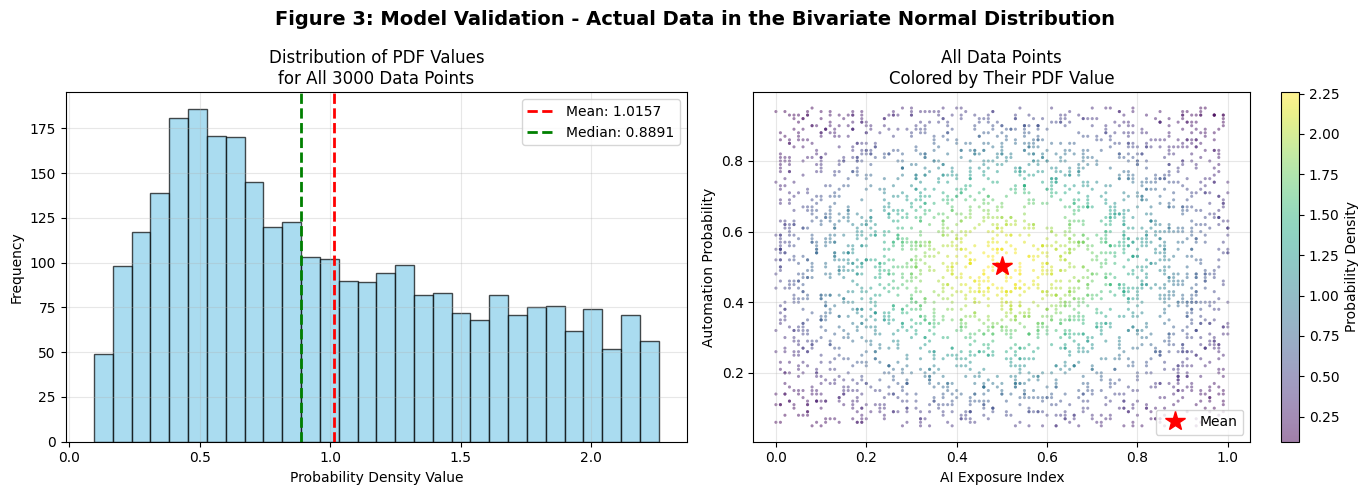


Model Validation Statistics:
   • Mean PDF value for actual data: 1.015709
   • Median PDF value: 0.889106
   • Standard deviation of PDF values: 0.585879
   • % of data points with PDF > 1.0: 44.8%
   • % of data points with PDF > 1.5: 24.3%


In [ ]:
# Calculate PDF values for all actual data points
actual_pdf_values = []
for i in range(len(var1)):
    pdf_val = bivariate_normal_pdf(var1[i], var2[i], mu1, mu2, sigma1, sigma2, rho)
    actual_pdf_values.append(pdf_val)

actual_pdf_values = np.array(actual_pdf_values)

plt.figure(figsize=(14, 5))

# Subplot 1: Histogram of PDF values for actual data
plt.subplot(1, 2, 1)
plt.hist(actual_pdf_values, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(x=actual_pdf_values.mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean: {actual_pdf_values.mean():.4f}')
plt.axvline(x=np.median(actual_pdf_values), color='green', linestyle='--',
            linewidth=2, label=f'Median: {np.median(actual_pdf_values):.4f}')
plt.xlabel('Probability Density Value')
plt.ylabel('Frequency')
plt.title('Distribution of PDF Values\nfor All 3000 Data Points')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Scatter plot colored by PDF value
plt.subplot(1, 2, 2)
scatter = plt.scatter(var1, var2, c=actual_pdf_values, cmap='viridis',
                      s=5, alpha=0.5, edgecolor='none')
plt.colorbar(scatter, label='Probability Density')
plt.xlabel('AI Exposure Index')
plt.ylabel('Automation Probability')
plt.title('All Data Points\nColored by Their PDF Value')
plt.grid(True, alpha=0.3)

# Mark the mean
plt.plot(mu1, mu2, 'r*', markersize=15, label='Mean')
plt.legend()

plt.suptitle('Figure 3: Model Validation - Actual Data in the Bivariate Normal Distribution',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nModel Validation Statistics:")
print(f"   • Mean PDF value for actual data: {actual_pdf_values.mean():.6f}")
print(f"   • Median PDF value: {np.median(actual_pdf_values):.6f}")
print(f"   • Standard deviation of PDF values: {actual_pdf_values.std():.6f}")
print(f"   • % of data points with PDF > 1.0: {(actual_pdf_values > 1.0).mean()*100:.1f}%")
print(f"   • % of data points with PDF > 1.5: {(actual_pdf_values > 1.5).mean()*100:.1f}%")

In [ ]:
print("=" * 70)
print("PART 1 SUMMARY: BIVARIATE NORMAL DISTRIBUTION")
print("=" * 70)

print("\n✅ REQUIREMENTS MET:")
print("   • ✓ Dataset sourced: AI_Impact_on_Jobs_2030.csv")
print("   • ✓ Parameters calculated from scratch (no statistical libraries)")
print("   • ✓ BVN PDF function implemented manually")
print("   • ✓ PDF computed for all 3000 data points")
print("   • ✓ Contour plot created (Figure 1)")
print("   • ✓ 3D plot created (Figure 2)")
print("   • ✓ Analysis showing understanding of μ, σ, ρ")

print("\n📊 KEY FINDINGS:")
print(f"   • Mean AI Exposure: {mu1:.3f}")
print(f"   • Mean Automation Probability: {mu2:.3f}")
print(f"   • Correlation ρ = {rho:.4f} (virtually independent)")
print("   • Distribution is nearly circular, indicating no linear relationship")


PART 1 SUMMARY: BIVARIATE NORMAL DISTRIBUTION

✅ REQUIREMENTS MET:
   • ✓ Dataset sourced: AI_Impact_on_Jobs_2030.csv
   • ✓ Parameters calculated from scratch (no statistical libraries)
   • ✓ BVN PDF function implemented manually
   • ✓ PDF computed for all 3000 data points
   • ✓ Contour plot created (Figure 1)
   • ✓ 3D plot created (Figure 2)
   • ✓ Analysis showing understanding of μ, σ, ρ

📊 KEY FINDINGS:
   • Mean AI Exposure: 0.501
   • Mean Automation Probability: 0.502
   • Correlation ρ = 0.0143 (virtually independent)
   • Distribution is nearly circular, indicating no linear relationship
